##  1. Preparación del Entorno
### 1.1: Instalación de dependencias


In [3]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib openpyxl nltk
!pip install sentence-transformers faiss-cpu langchain langchain-community langchain-huggingface
                
import nltk

nltk.download('stopwords', download_dir=None, quiet=False)
nltk.download('punkt', download_dir=None, quiet=False)
nltk.download('wordnet', download_dir=None, quiet=False)

# Verificar que se descargaron
print("Stopwords disponibles:", len(nltk.corpus.stopwords.words('spanish')))
print("✅ Datos de NLTK descargados correctamente")

Stopwords disponibles: 313
✅ Datos de NLTK descargados correctamente


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hirag\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hirag\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hirag\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### 1.2: Configuración Inicial del Entorno

In [4]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

##  2: Carga y Exploración de Datos
### 2.1: Carga del Dataset

In [5]:
df = pd.read_excel('Corpus_Noticias_Falsas.xlsx', sheet_name='corpus')

print("Dimensiones del dataset:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nDistribución de clases:")
print(df['Categoria'].value_counts())

df.head()

Dimensiones del dataset: (634, 7)

Columnas: ['ID', 'Categoria', 'Tema', 'Origen', 'Titulo', 'Texto', 'Fuente']

Distribución de clases:
Categoria
Noticia Real     317
Noticia Falsa    317
Name: count, dtype: int64


,ID,Categoria,Tema,Origen,Titulo,Texto,Fuente
0,1,Noticia Real,Politico,El tiempo,Duque dice que Eln se adjudicó atentado y busc...,El presidente Iván Duque condenó fuertemente e...,https://www.eltiempo.com/politica/gobierno/eln...
1,2,Noticia Real,Politico,El espectador,"Gustavo Petro se reunirá con Pedro Sánchez, pr...","Gustavo Petro se reunirá con Pedro Sánchez, pr...",https://www.elespectador.com/politica/?utm_sou...
2,3,Noticia Real,Politico,El tiempo,Marta Lucía Ramírez se queja por servicio en e...,Marta Lucía Ramírez se queja por servicio en e...,https://www.eltiempo.com/politica/gobierno/mar...
3,4,Noticia Real,Politico,El espectador,"Elecciones de 2022 requieren mayor cuidado, po...","Elecciones de 2022 requieren mayor cuidado, po...",https://www.elespectador.com/politica/eleccion...
4,5,Noticia Real,Politico,El Nuevo Siglo,Procuraduría citó a mandatarios por fiestas en...,ANTE LA expansión de la variante ómicron en el...,https://www.elnuevosiglo.com.co/articulos/01-0...


### 2.2: Preprocesamiento de Texto

In [1]:
import re

def preprocess_text_ultra_simple(text):
    if not isinstance(text, str) or pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|@\S+|#\S+', '', text)
    text = re.sub(r'[^a-záéíóúñ\s]', '', text)
    # Solo eliminar palabras muy cortas
    words = text.split()
    words = [w for w in words if len(w) > 2]
    return ' '.join(words)

df['clean_text'] = df['Texto'].apply(preprocess_text_ultra_simple)

print("✅ Preprocesamiento ultra simple completado")
df[['Texto', 'clean_text']].head(3)

NameError: name 'df' is not defined

##  3: Modelos Clásicos de
### 3.1: Vectorización TF-IDF

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorización
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = tfidf.fit_transform(df['clean_text'])
y = df['Categoria']

print("✅ Vectorización completada")
print("Forma de la matriz TF-IDF:", X.shape)
print("\nDistribución de clases:")
print(y.value_counts())

✅ Vectorización completada
Forma de la matriz TF-IDF: (634, 5000)

Distribución de clases:
Categoria
Noticia Real     317
Noticia Falsa    317
Name: count, dtype: int64


### 3.2: División del Dataset (Train/Test)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape[0], "registros")
print("Test:", X_test.shape[0], "registros")

Train: 507 registros
Test: 127 registros


### 3.3: Entrenamiento y Evaluación de Modelos Tradicionales

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, f1_score

models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": SVC(kernel='linear', probability=True)
}

results = {}
best_model_name = ""
best_f1 = 0
best_model = None

print("Entrenando y evaluando modelos...\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results[name] = {"Accuracy": acc, "F1-Score": f1}
    
    print(f"=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("-" * 40)
    
    # Guardar el mejor según F1-Score
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_model = model

# Mostrar el ganador
print(f"\n🏆 MEJOR MODELO: **{best_model_name}**")
print(f"F1-Score: {best_f1:.4f}")

# Guardar el mejor modelo y el vectorizador
joblib.dump(best_model, f'mejor_modelo_{best_model_name.replace(" ", "_")}.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print(f"\n✅ Modelo guardado como: mejor_modelo_{best_model_name.replace(' ', '_')}.pkl")

Entrenando y evaluando modelos...

=== Random Forest ===
Accuracy : 0.9055
F1-Score : 0.9051
----------------------------------------
=== Logistic Regression ===
Accuracy : 0.9055
F1-Score : 0.9054
----------------------------------------
=== Naive Bayes ===
Accuracy : 0.8661
F1-Score : 0.8660
----------------------------------------
=== SVM ===
Accuracy : 0.9213
F1-Score : 0.9212
----------------------------------------

🏆 MEJOR MODELO: **SVM**
F1-Score: 0.9212

✅ Modelo guardado como: mejor_modelo_SVM.pkl


### 3.4: evaluador Matriz de Confusión 

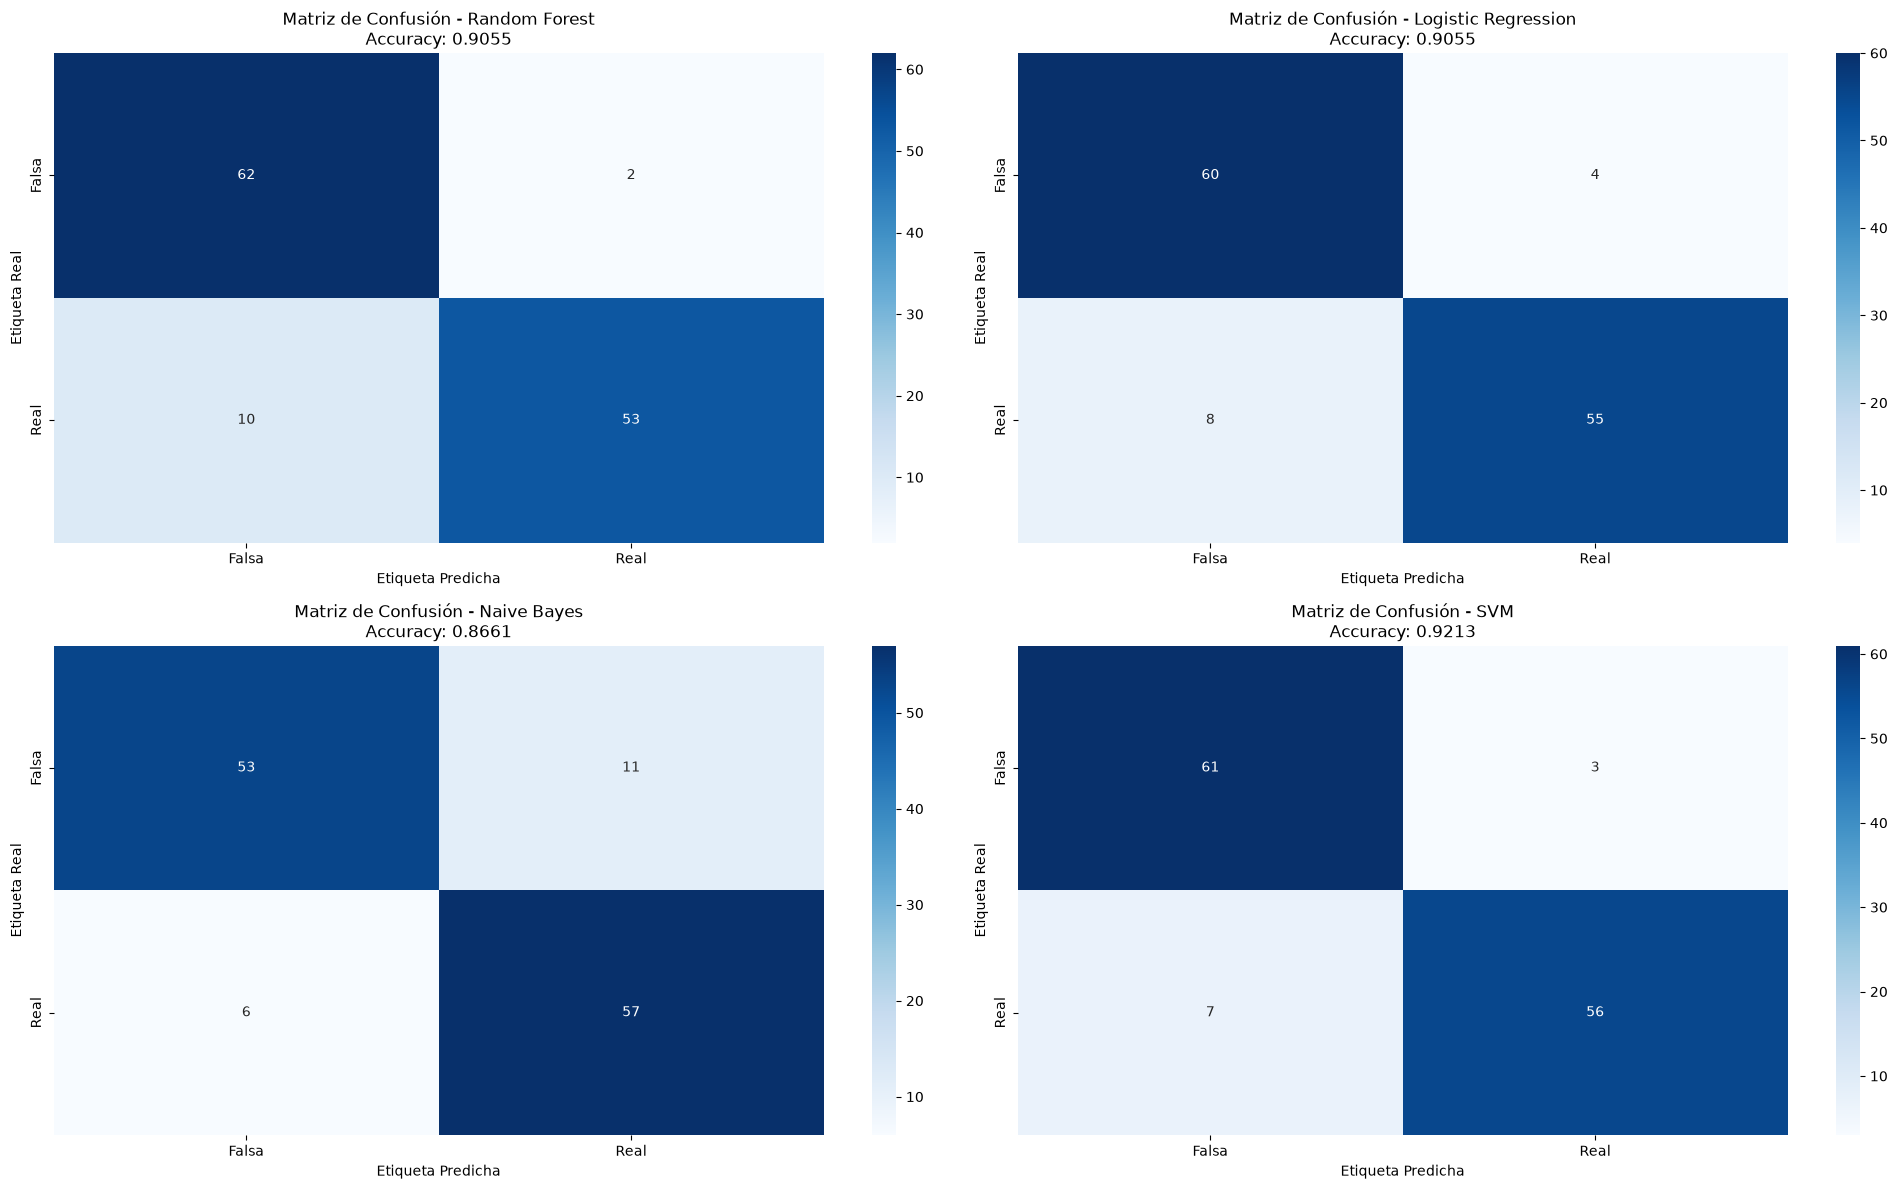

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(20, 12))

for i, (name, model) in enumerate(models.items(), 1):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.subplot(2, 2, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Falsa', 'Real'],
                yticklabels=['Falsa', 'Real'])
    plt.title(f'Matriz de Confusión - {name}\nAccuracy: {results[name]["Accuracy"]:.4f}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Etiqueta Predicha')

plt.tight_layout()
plt.show()

### 3.5: evaluador Accuracy y F1-Score

<Figure size 1200x700 with 0 Axes>

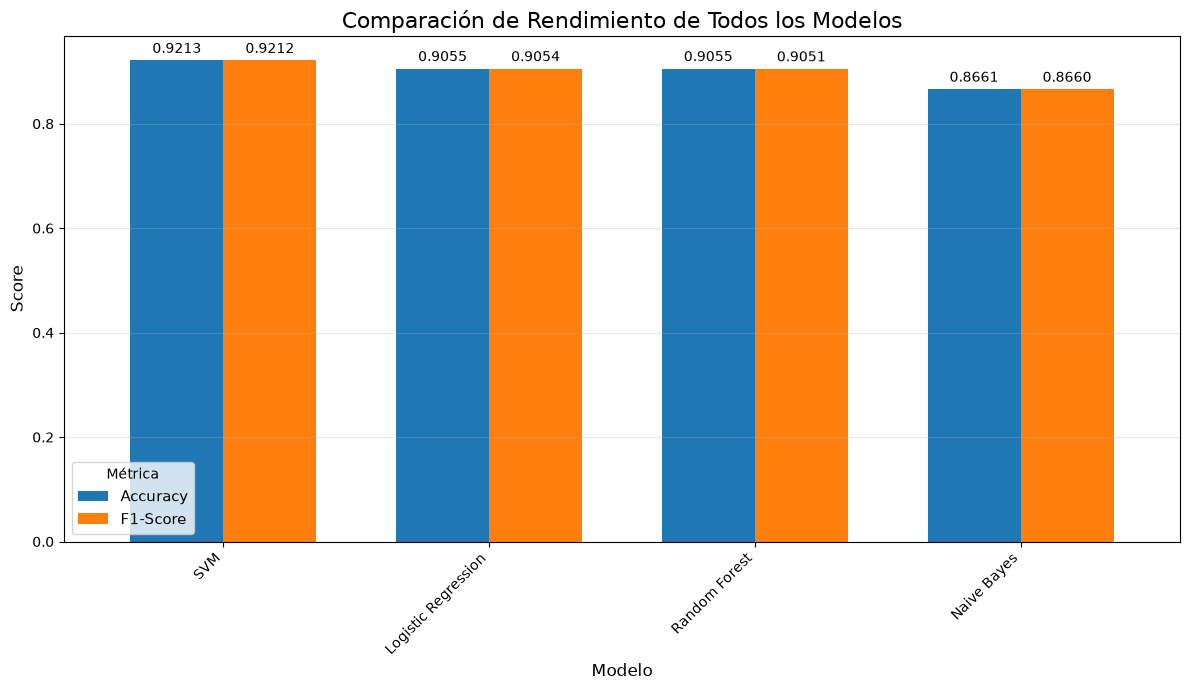


📊 Tabla de Resultados:
                     Accuracy  F1-Score
SVM                    0.9213    0.9212
Logistic Regression    0.9055    0.9054
Random Forest          0.9055    0.9051
Naive Bayes            0.8661    0.8660


In [12]:
import pandas as pd

# Crear DataFrame con resultados
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='F1-Score', ascending=False)

# Gráfico
plt.figure(figsize=(12, 7))
ax = results_df.plot(kind='bar', figsize=(12, 7), 
                     color=['#1f77b4', '#ff7f0e'], width=0.7)

plt.title('Comparación de Rendimiento de Todos los Modelos', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Métrica', fontsize=11)
plt.grid(axis='y', alpha=0.3)

# Mostrar valores encima de las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

# Mostrar tabla numérica
print("\n📊 Tabla de Resultados:")
print(results_df.round(4))

### 3.6: evaluador curva ROC

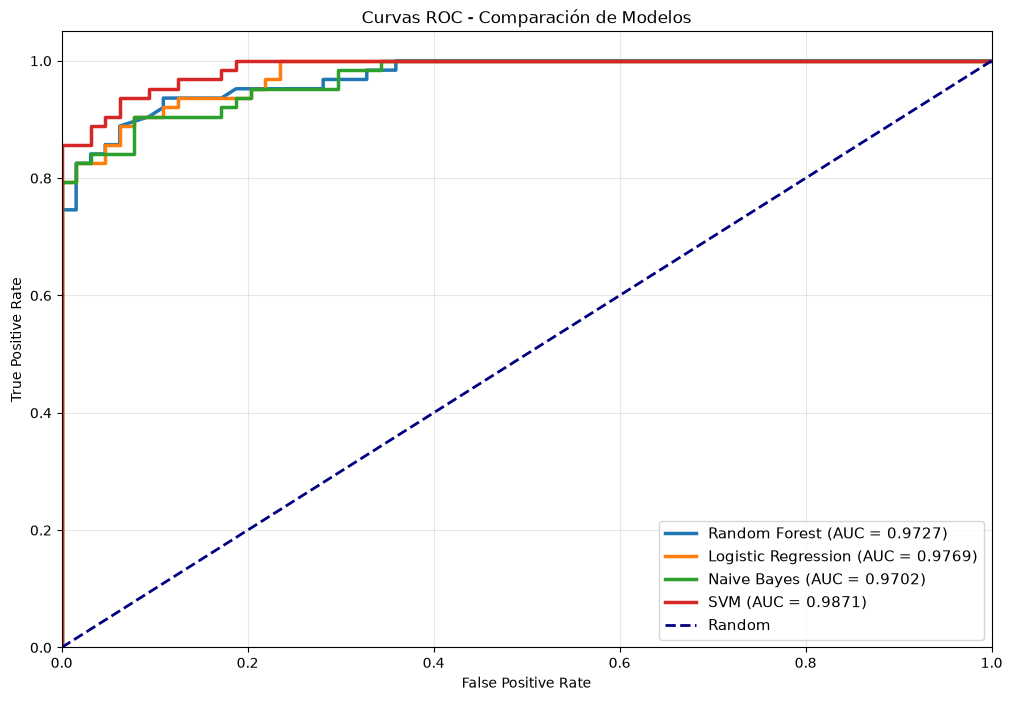

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Binarizar las etiquetas reales
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

plt.figure(figsize=(12, 8))

for name, model in models.items():
    try:
        # Obtener scores de probabilidad
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]  # Probabilidad de clase positiva
        else:
            # Para modelos sin predict_proba (como SVM linear)
            y_score = model.decision_function(X_test)
            # Normalizar a rango [0,1]
            y_score = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-8)
        
        # Calcular curva ROC
        fpr, tpr, _ = roc_curve(y_test_bin, y_score)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, lw=2.5, label=f'{name} (AUC = {roc_auc:.4f})')
        
    except Exception as e:
        print(f"Error con {name}: {e}")

# Línea de referencia
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC - Comparación de Modelos')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
from sklearn.metrics import classification_report
import pandas as pd

print("📊 MÉTRICAS DETALLADAS POR CLASE\n")

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    print(f"{'='*60}")
    print(f"🔸 {name.upper()}")
    print(f"{'='*60}")
    
    # Reporte completo por clase
    report = classification_report(y_test, y_pred, 
                                   target_names=['Noticia Falsa', 'Noticia Real'],
                                   output_dict=True)
    
    # Mostrar como tabla bonita
    df_report = pd.DataFrame(report).T.round(4)
    print(df_report)
    print("\n")

📊 MÉTRICAS DETALLADAS POR CLASE

🔸 RANDOM FOREST
               precision  recall  f1-score   support
Noticia Falsa     0.8611  0.9688    0.9118   64.0000
Noticia Real      0.9636  0.8413    0.8983   63.0000
accuracy          0.9055  0.9055    0.9055    0.9055
macro avg         0.9124  0.9050    0.9050  127.0000
weighted avg      0.9120  0.9055    0.9051  127.0000


🔸 LOGISTIC REGRESSION
               precision  recall  f1-score   support
Noticia Falsa     0.8824  0.9375    0.9091   64.0000
Noticia Real      0.9322  0.8730    0.9016   63.0000
accuracy          0.9055  0.9055    0.9055    0.9055
macro avg         0.9073  0.9053    0.9054  127.0000
weighted avg      0.9071  0.9055    0.9054  127.0000


🔸 NAIVE BAYES
               precision  recall  f1-score   support
Noticia Falsa     0.8983  0.8281    0.8618   64.0000
Noticia Real      0.8382  0.9048    0.8702   63.0000
accuracy          0.8661  0.8661    0.8661    0.8661
macro avg         0.8683  0.8664    0.8660  127.0000
weighted a

##  4: Sistema RAG + LLM
### 4.1: Construcción del Sistema RAG (Retrieval-Augmented Generation)

In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import pickle
from sklearn.metrics.pairwise import cosine_similarity

# Cargar dataset
df = pd.read_excel('Corpus_Noticias_Falsas.xlsx', sheet_name='corpus')
print("Dataset cargado:", df.shape)

# Preparar documentos para RAG
documents = []
for _, row in df.iterrows():
    doc = f"Título: {row['Titulo']}\nTexto: {row['Texto']}\nCategoría: {row['Categoria']}"
    documents.append(doc)

# Crear embeddings
print("Creando embeddings...")
model_embed = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')  # Bueno para español
embeddings = model_embed.encode(documents, show_progress_bar=True)

# Crear índice FAISS
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings.astype('float32'))

print("✅ Índice RAG creado con", len(documents), "documentos")

Dataset cargado: (634, 7)
Creando embeddings...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

✅ Índice RAG creado con 634 documentos


### 4.2: Generación de Embeddings y Índice FAISS

In [2]:
def detectar_noticia_falsa_rag(texto_nuevo, k=5):
    """
    Detecta si una noticia es falsa usando RAG básico
    """
    # Embedding de la consulta
    query_embedding = model_embed.encode([texto_nuevo])
    
    # Recuperar los k documentos más similares
    distances, indices = index.search(query_embedding.astype('float32'), k)
    
    # Construir contexto
    contexto = "\n\n---\n\n".join([documents[i] for i in indices[0]])
    
    # Prompt para razonamiento (puedes usar con Ollama o Grok)
    prompt = f"""Eres un experto en detección de noticias falsas en contexto colombiano.
    
Contexto de noticias reales y falsas conocidas:
{contexto}

Noticia a analizar:
{texto_nuevo}

Responde SOLO con formato JSON:
{{
  "veredicto": "REAL" o "FALSA",
  "confianza": número entre 0 y 1,
  "explicacion": "explicación breve y clara"
}}
"""

    return {
        "prompt": prompt,
        "contexto_recuperado": contexto,
        "indices": indices[0]
    }

# Ejemplo de uso
ejemplo = df['Texto'].iloc[11]  # Una noticia real
resultado = detectar_noticia_falsa_rag(ejemplo)
print(resultado['prompt'][:800] + "...")  # Muestra parte del prompt

Eres un experto en detección de noticias falsas en contexto colombiano.

Contexto de noticias reales y falsas conocidas:
Título: Registraduría acepta fallas en inscripción virtual de cédulas 
Texto: Registraduría acepta fallas en inscripción virtual de cédulas Después de varias denuncias de usuarios en redes sociales, la Registraduría Nacional del Estado Civil confirmó que se han presentado varias fallas técnicas que han impedido el proceso de inscripción de cédulas de ciudadanía para las próximas elecciones al Congreso, que están programadas a realizarse el 13 de marzo.
Categoría: Noticia Real

---

Título: Registraduría asegura que plataforma para inscripción de cédulas ya funciona normalmente
Texto: Registraduría asegura que plataforma para inscripción de cédulas ya funciona normalmente...


### 4.3: Evaluar el sistema

In [4]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

def detectar_noticia_falsa_rag_mejorado(texto_nuevo, k=7):
    """Versión mejorada del RAG"""
    query_embedding = model_embed.encode([texto_nuevo])
    
    distances, indices = index.search(query_embedding.astype('float32'), k)
    
    # Recuperar documentos similares
    docs_similares = [documents[i] for i in indices[0]]
    etiquetas_similares = [df.iloc[i]['Categoria'] for i in indices[0]]
    
    # Conteo simple de votos
    conteo = pd.Series(etiquetas_similares).value_counts()
    veredicto = conteo.index[0]  # El que más aparece
    confianza = conteo.iloc[0] / k
    
    # Explicación básica
    explicacion = f"Se encontraron {conteo.get('Noticia Real', 0)} noticias reales y {conteo.get('Noticia Falsa', 0)} falsas similares."
    
    return {
        "veredicto": veredicto,
        "confianza": float(confianza),
        "explicacion": explicacion,
        "etiquetas_recuperadas": etiquetas_similares
    }


# === Evaluación correcta ===
def evaluar_rag_mejorado(df_eval):
    predicciones = []
    y_true = []
    
    for idx, row in df_eval.iterrows():
        resultado = detectar_noticia_falsa_rag_mejorado(row['Texto'], k=7)
        predicciones.append(1 if resultado['veredicto'] == "Noticia Falsa" else 0)
        y_true.append(1 if row['Categoria'] == "Noticia Falsa" else 0)
    
    acc = accuracy_score(y_true, predicciones)
    f1 = f1_score(y_true, predicciones, average='weighted')
    
    print(f"✅ Accuracy: {acc:.4f}")
    print(f"✅ F1-Score: {f1:.4f}")
    print("\nReporte detallado:")
    print(classification_report(y_true, predicciones, target_names=['Real', 'Falsa']))
    
    return acc, f1


# Ejecutar evaluación
print("Evaluando RAG mejorado...")
df_sample = df.sample(200, random_state=42)   # Puedes aumentar el tamaño
evaluar_rag_mejorado(df_sample)

Evaluando RAG mejorado...
✅ Accuracy: 0.8200
✅ F1-Score: 0.8173

Reporte detallado:
              precision    recall  f1-score   support

        Real       0.74      0.97      0.84        95
       Falsa       0.96      0.69      0.80       105

    accuracy                           0.82       200
   macro avg       0.85      0.83      0.82       200
weighted avg       0.85      0.82      0.82       200



(0.82, 0.8172727272727272)

### 4.4: implementación ollama
### 4.4.1: instalación

In [9]:
from langchain_community.llms import Ollama

llm = Ollama(model="llama3.2:1b", temperature=0.1)

def predecir_con_llm(texto):
    rag_info = detectar_noticia_falsa_rag(texto)
    response = llm.invoke(rag_info['prompt'])
    print(response)
    return response

C:\Users\hirag\AppData\Local\Temp\ipykernel_9468\1069813342.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.llms import Ollama
C:\Users\hirag\AppData\Local\Temp\ipykernel_9468\1069813342.py:3: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  llm = Ollama(model="llama3.2:1b", temperature=0.1)


### 4.4.2: modelo mistral:7b

In [ ]:
# ==================== INSTALAR DEPENDENCIAS ====================
!pip install langchain langchain-community langchain-huggingface sentence-transformers faiss-cpu

# ==================== IMPORTS ====================
from langchain_community.llms import Ollama
from langchain_core.prompts import PromptTemplate
import pandas as pd

# ==================== CARGAR MODELO MÁS POTENTE ====================
llm = Ollama(
    model="mistral:7b",      # ← Cambiado aquí
    temperature=0.0,         # Más determinista
    num_ctx=8192,
    top_p=0.9
)

print("✅ Usando Mistral 7B")

✅ Usando Mistral 7B


### 4.4.2: Evaluación Completa del Sistema RAG + Ollama 

In [11]:
# ==================== PROMPT ====================

def detectar_con_rag_ollama(texto_nuevo, k=6):
    """RAG con Mistral + Prompt más fuerte"""
    
    query_embedding = model_embed.encode([texto_nuevo])
    distances, indices = index.search(query_embedding.astype('float32'), k)
    
    contexto_docs = []
    for i in indices[0]:
        row = df.iloc[i]
        contexto_docs.append(
            f"TÍTULO: {row['Titulo']}\n"
            f"TEXTO: {row['Texto'][:500]}...\n"
            f"CATEGORÍA: {row['Categoria']}\n"
        )
    
    contexto = "\n\n" + "="*50 + "\n\n".join(contexto_docs)
    
    prompt = f"""Eres un experto analista de noticias falsas en Colombia, especializado en política.

**Instrucciones:**
- Analiza solo el contenido de la noticia.
- Compara con las noticias similares del contexto.
- Sé objetivo y riguroso.
- No inventes información.

**Contexto de noticias reales y falsas similares:**
{contexto}

**Noticia a evaluar:**
{texto_nuevo}

Responde **únicamente** con un JSON válido y nada más:

{{
  "veredicto": "REAL" o "FALSA",
  "confianza": número entre 0.0 y 1.0,
  "razonamiento": "explicación clara y concisa en español (máximo 2-3 oraciones)",
  "indicios_principales": ["indicio1", "indicio2"]
}}

JSON:
"""

    respuesta = llm.invoke(prompt)
    
    return {
        "veredicto": respuesta,
        "contexto": contexto,
        "prompt": prompt
    }

# ==================== FUNCIÓN PARA PROBAR ====================
def probar_noticia(texto):
    resultado = detectar_con_rag_ollama(texto, k=6)
    print("🧠 RESPUESTA DEL LLM:\n")
    print(resultado["veredicto"])
    return resultado

In [14]:
# Prueba con la misma noticia que falló antes
indice_prueba = 45
texto_prueba = df['Texto'].iloc[indice_prueba]

print("Categoría real:", df['Categoria'].iloc[indice_prueba])
print("="*80)

resultado = detectar_con_rag_ollama(texto_prueba, k=6)
print(resultado["veredicto"])

Categoría real: Noticia Falsa
 {
  "veredicto": "FALSA",
  "confianza": 1.0,
  "razonamiento": "El Doctor Petro no es el presidente de Colombia y no tiene autoridad para crear cargos en la Procuraduría General de la Nación. Además, no hay evidencia que apoye la afirmación de que él interpuso una demanda para crear los 1200 cargos nuevos.",
  "indicios_principales": ["El Doctor Petro no es el presidente", "No hay evidencia de que él interpuso una demanda para crear los 1200 cargos"]
}


### 4.4.3: Sistema RAG + Ollama

Evaluando 120 noticias con RAG + Mistral...

Procesadas 10/120 noticias...
Procesadas 20/120 noticias...
Procesadas 30/120 noticias...
Procesadas 40/120 noticias...
Procesadas 50/120 noticias...
Procesadas 60/120 noticias...
Procesadas 70/120 noticias...
Procesadas 80/120 noticias...
Procesadas 90/120 noticias...
Procesadas 100/120 noticias...
Procesadas 110/120 noticias...
Procesadas 120/120 noticias...

📊 RESULTADOS DE EVALUACIÓN RAG + OLLAMA
Accuracy     : 0.9583
F1-Score     : 0.9565
Precision    : 1.0000
Recall       : 0.9167
ROC AUC      : 0.9882

               precision    recall  f1-score   support

 Noticia Real       0.92      1.00      0.96        60
Noticia Falsa       1.00      0.92      0.96        60

     accuracy                           0.96       120
    macro avg       0.96      0.96      0.96       120
 weighted avg       0.96      0.96      0.96       120



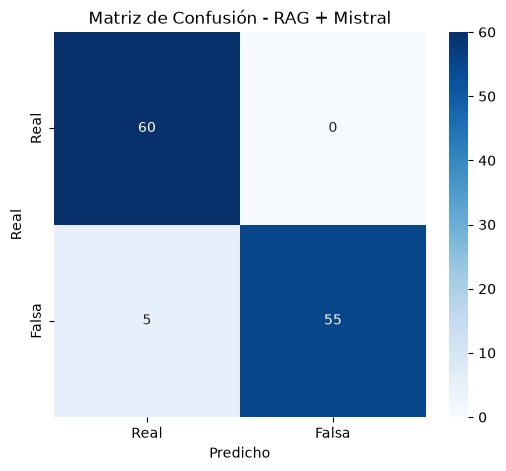

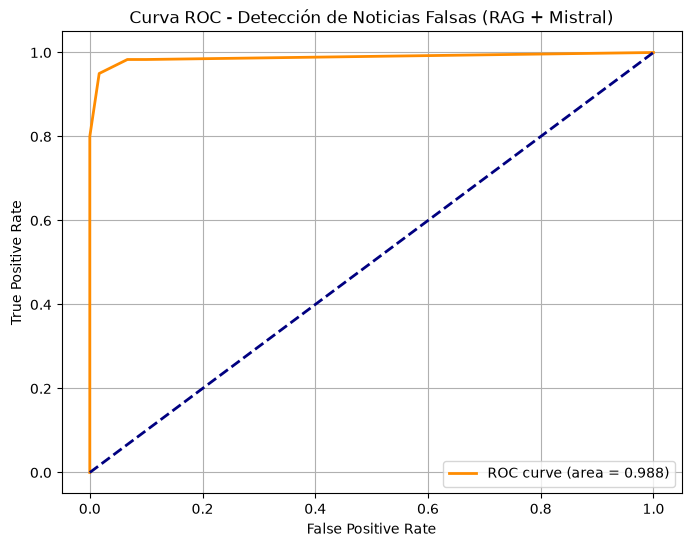


✅ Resultados guardados en 'resultados_rag_ollama.csv'


In [44]:
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, 
    classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
)
import seaborn as sns

# ==================== FUNCIÓN PARA EXTRAER JSON DEL LLM ====================
def extraer_json_llm(respuesta_texto):
    """Extrae de forma robusta el JSON de la respuesta de Mistral"""
    try:
        # Buscar JSON en la respuesta
        json_match = re.search(r'\{.*\}', respuesta_texto, re.DOTALL)
        if json_match:
            json_str = json_match.group(0)
            data = json.loads(json_str)
            return data
    except:
        pass
    
    # Fallback: búsqueda manual
    if "FALSA" in respuesta_texto.upper() and "REAL" not in respuesta_texto.upper():
        veredicto = "Noticia Falsa"
    elif "REAL" in respuesta_texto.upper():
        veredicto = "Noticia Real"
    else:
        veredicto = "Desconocido"
    
    return {
        "veredicto": veredicto,
        "confianza": 0.5,
        "razonamiento": "No se pudo parsear JSON"
    }


# ==================== EVALUACIÓN COMPLETA ====================
def evaluar_rag_ollama(df_eval, k=6, sample_size=None):
    if sample_size is not None:
        df_eval = df_eval.sample(sample_size, random_state=42)
    
    y_true = []
    y_pred = []
    y_scores = []      # Para ROC (confianza)
    resultados = []
    
    print(f"Evaluando {len(df_eval)} noticias con RAG + Mistral...\n")
    
    for idx, row in df_eval.iterrows():
        texto = row['Texto']
        categoria_real = row['Categoria']
        
        # Llamada al RAG + Ollama
        res = detectar_con_rag_ollama(texto, k=k)
        respuesta_llm = res['veredicto']
        
        # Parsear respuesta
        parsed = extraer_json_llm(respuesta_llm)
        
        veredicto = parsed.get('veredicto', 'Desconocido')
        confianza = parsed.get('confianza', 0.5)
        
        # Convertir a binario (1 = Falsa, 0 = Real)
        pred_bin = 1 if "FALSA" in veredicto.upper() else 0
        true_bin = 1 if "FALSA" in categoria_real.upper() else 0
        
        y_true.append(true_bin)
        y_pred.append(pred_bin)
        y_scores.append(confianza if pred_bin == 1 else 1 - confianza)  # Ajuste para ROC
        
        resultados.append({
            'indice': idx,
            'categoria_real': categoria_real,
            'veredicto_llm': veredicto,
            'confianza': confianza,
            'correcto': pred_bin == true_bin
        })
        
        if len(resultados) % 10 == 0:
            print(f"Procesadas {len(resultados)}/{len(df_eval)} noticias...")
    
    # ==================== MÉTRICAS ====================
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)
    
    print("\n" + "="*60)
    print("📊 RESULTADOS DE EVALUACIÓN RAG + OLLAMA")
    print("="*60)
    
    print(f"Accuracy     : {accuracy_score(y_true, y_pred):.4f}")
    print(f"F1-Score     : {f1_score(y_true, y_pred):.4f}")
    print(f"Precision    : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall       : {recall_score(y_true, y_pred):.4f}")
    print(f"ROC AUC      : {roc_auc_score(y_true, y_scores):.4f}")
    
    print("\n" + classification_report(y_true, y_pred, target_names=['Noticia Real', 'Noticia Falsa']))
    
    # ==================== MATRIZ DE CONFUSIÓN ====================
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Real', 'Falsa'], 
                yticklabels=['Real', 'Falsa'])
    plt.title('Matriz de Confusión - RAG + Mistral')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()
    
    # ==================== CURVA ROC ====================
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Curva ROC - Detección de Noticias Falsas (RAG + Mistral)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
    
    # Guardar resultados
    df_resultados = pd.DataFrame(resultados)
    df_resultados.to_csv('resultados_rag_ollama.csv', index=False)
    print(f"\n✅ Resultados guardados en 'resultados_rag_ollama.csv'")
    
    return df_resultados


# ==================== EJECUTAR EVALUACIÓN ====================
# Recomendado: usar 100-200 muestras (Mistral es lento)
df_resultados = evaluar_rag_ollama(df, k=6, sample_size=120)

Evaluando 20 noticias con RAG + Mistral...

Procesadas 10/20 noticias...
Procesadas 20/20 noticias...

📊 RESULTADOS DE EVALUACIÓN RAG + OLLAMA
Accuracy     : 0.9500
F1-Score     : 0.9474
Precision    : 1.0000
Recall       : 0.9000
ROC AUC      : 0.9950

               precision    recall  f1-score   support

 Noticia Real       0.91      1.00      0.95        10
Noticia Falsa       1.00      0.90      0.95        10

     accuracy                           0.95        20
    macro avg       0.95      0.95      0.95        20
 weighted avg       0.95      0.95      0.95        20



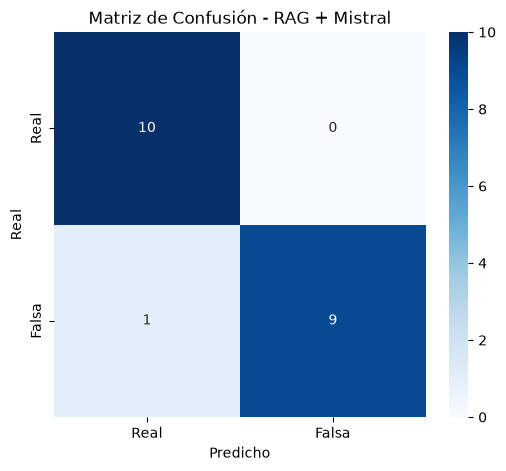

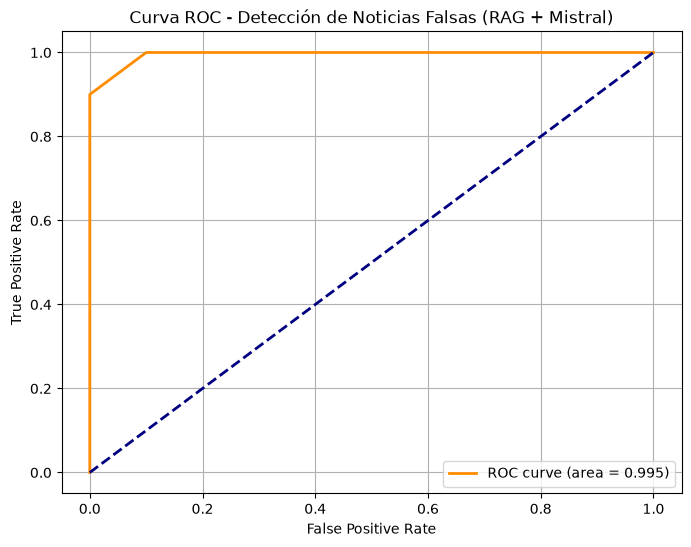


✅ Resultados guardados en 'resultados_rag_ollama.csv'


In [ ]:
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, 
    classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
)
import seaborn as sns

# ==================== FUNCIÓN PARA EXTRAER JSON DEL LLM ====================
def extraer_json_llm(respuesta_texto):
    """Extrae de forma robusta el JSON de la respuesta de Mistral"""
    try:
        # Buscar JSON en la respuesta
        json_match = re.search(r'\{.*\}', respuesta_texto, re.DOTALL)
        if json_match:
            json_str = json_match.group(0)
            data = json.loads(json_str)
            return data
    except:
        pass
    
    # Fallback: búsqueda manual
    if "FALSA" in respuesta_texto.upper() and "REAL" not in respuesta_texto.upper():
        veredicto = "Noticia Falsa"
    elif "REAL" in respuesta_texto.upper():
        veredicto = "Noticia Real"
    else:
        veredicto = "Desconocido"
    
    return {
        "veredicto": veredicto,
        "confianza": 0.5,
        "razonamiento": "No se pudo parsear JSON"
    }


# ==================== EVALUACIÓN COMPLETA ====================
def evaluar_rag_ollama(df_eval, k=6, sample_size=None):
    if sample_size is not None:
        df_eval = df_eval.sample(sample_size, random_state=42)
    
    y_true = []
    y_pred = []
    y_scores = []      # Para ROC (confianza)
    resultados = []
    
    print(f"Evaluando {len(df_eval)} noticias con RAG + Mistral...\n")
    
    for idx, row in df_eval.iterrows():
        texto = row['Texto']
        categoria_real = row['Categoria']
        
        # Llamada al RAG + Ollama
        res = detectar_con_rag_ollama(texto, k=k)
        respuesta_llm = res['veredicto']
        
        # Parsear respuesta
        parsed = extraer_json_llm(respuesta_llm)
        
        veredicto = parsed.get('veredicto', 'Desconocido')
        confianza = parsed.get('confianza', 0.5)
        
        # Convertir a binario (1 = Falsa, 0 = Real)
        pred_bin = 1 if "FALSA" in veredicto.upper() else 0
        true_bin = 1 if "FALSA" in categoria_real.upper() else 0
        
        y_true.append(true_bin)
        y_pred.append(pred_bin)
        y_scores.append(confianza if pred_bin == 1 else 1 - confianza)  # Ajuste para ROC
        
        resultados.append({
            'indice': idx,
            'categoria_real': categoria_real,
            'veredicto_llm': veredicto,
            'confianza': confianza,
            'correcto': pred_bin == true_bin
        })
        
        if len(resultados) % 10 == 0:
            print(f"Procesadas {len(resultados)}/{len(df_eval)} noticias...")
    
    # ==================== MÉTRICAS ====================
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)
    
    print("\n" + "="*60)
    print("📊 RESULTADOS DE EVALUACIÓN RAG + OLLAMA")
    print("="*60)
    
    print(f"Accuracy     : {accuracy_score(y_true, y_pred):.4f}")
    print(f"F1-Score     : {f1_score(y_true, y_pred):.4f}")
    print(f"Precision    : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall       : {recall_score(y_true, y_pred):.4f}")
    print(f"ROC AUC      : {roc_auc_score(y_true, y_scores):.4f}")
    
    print("\n" + classification_report(y_true, y_pred, target_names=['Noticia Real', 'Noticia Falsa']))
    
    # ==================== MATRIZ DE CONFUSIÓN ====================
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Real', 'Falsa'], 
                yticklabels=['Real', 'Falsa'])
    plt.title('Matriz de Confusión - RAG + Mistral')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()
    
    # ==================== CURVA ROC ====================
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Curva ROC - Detección de Noticias Falsas (RAG + Mistral)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
    
    # Guardar resultados
    df_resultados = pd.DataFrame(resultados)
    df_resultados.to_csv('resultados_rag_ollama1.csv', index=False)
    print(f"\n✅ Resultados guardados en 'resultados_rag_ollama1.csv'")
    
    return df_resultados


# ==================== EJECUTAR EVALUACIÓN ====================
# Recomendado: usar 100-200 muestras (Mistral es lento)
df_resultados = evaluar_rag_ollama(df, k=6, sample_size=20)